Loading data...
Train: 667
Test: 143

Train distribution:
hungry        267
belly_pain    100
burping       100
discomfort    100
tired         100
Name: count, dtype: int64

Test distribution:
hungry        115
tired           9
discomfort      9
belly_pain      6
burping         4
Name: count, dtype: int64

Training...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV score: 0.9342156173220226

Testing...

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.67      0.67      0.67         6
     burping       0.67      0.50      0.57         4
  discomfort       0.75      0.33      0.46         9
      hungry       0.89      0.97      0.93       115
       tired       0.60      0.33      0.43         9

    accuracy                           0.86       143
   macro avg       0.71      0.56      0.61       143
weighted avg       0.85      0.86     

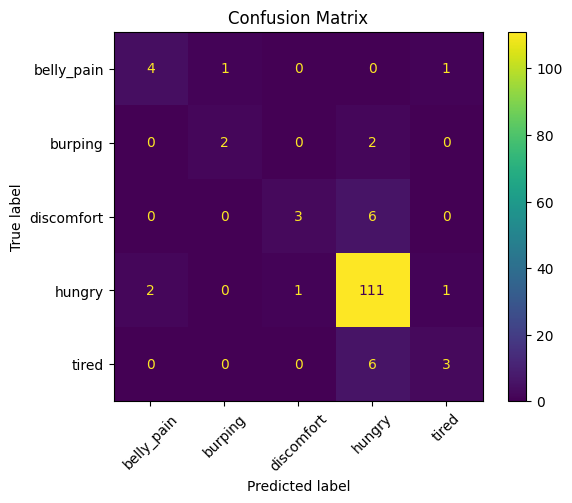

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# ================= CONFIG =================
CONFIG = {
    "train_root": "data/corpus/donatecry_copus_split_data/train_augumentation",
    "test_root": "data/corpus/donatecry_copus_split_data/test",
    "sample_rate": 16000, # 16000
    "n_mfcc": 20, #40
    "n_fft": 1024, #1024, 2048
    "hop_length": 160,   # 160, 512, 
    "n_mels": 40,
    "fmin": 0,
    "fmax": 8000,
}

# ================= FEATURE =================
def extract_mfcc(y, sr, cfg):
    return librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=cfg["n_mfcc"],
        n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"],
        n_mels=cfg["n_mels"],
        fmin=cfg["fmin"],
        fmax=cfg["fmax"],
    )

def extract_features_from_file(path, cfg):
    y, sr = librosa.load(path, sr=cfg["sample_rate"], mono=True)

    mfcc = extract_mfcc(y, sr, cfg)
    # mfcc_delta = librosa.feature.delta(mfcc)
    # mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # ===== FEATURE ENGINEERING =====
    mean = np.mean(mfcc, axis=1)
    std = np.std(mfcc, axis=1)
    # delta_mean = np.mean(mfcc_delta, axis=1)
    # delta_std = np.std(mfcc_delta, axis=1)
    # delta_mean = np.mean(mfcc_delta, axis=1)
    # delta_std = np.std(mfcc_delta, axis=1)
    # delta2_mean = np.mean(mfcc_delta2, axis=1)
    # delta2_std = np.std(mfcc_delta2, axis=1)
    # return np.concatenate([mean, std])  # shape (80,)
    return np.concatenate([
    mean, std,
    # delta_mean, delta_std,
    # delta2_mean, delta2_std
])

# ================= DATA =================
def load_dataset(root, cfg):
    X, y = [], []

    for label in os.listdir(root):
        label_path = os.path.join(root, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.endswith(".wav"):
                    path = os.path.join(label_path, file)

                    try:
                        feat = extract_features_from_file(path, cfg)
                        X.append(feat)
                        y.append(label)
                    except Exception as e:
                        print(f"❌ lỗi {file}: {e}")

    return np.array(X), np.array(y)

# ================= MAIN =================
def main():
    cfg = CONFIG

    print("Loading data...")

    X_train, y_train = load_dataset(cfg["train_root"], cfg)
    X_test, y_test = load_dataset(cfg["test_root"], cfg)

    print("Train:", len(X_train))
    print("Test:", len(X_test))

    print("\nTrain distribution:")
    print(pd.Series(y_train).value_counts())

    print("\nTest distribution:")
    print(pd.Series(y_test).value_counts())

    # ===== ENCODE LABEL =====
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # ===== MODEL =====
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(class_weight="balanced"))
    ])

    param_grid = {
        "svm__kernel": ["rbf", 'linear'],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", "auto"]
    }

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_macro",
        verbose=2,
        n_jobs=-1
    )

    print("\nTraining...")
    grid.fit(X_train, y_train_enc)

    print("\nBest params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)

    # ================= TEST =================
    print("\nTesting...")

    y_pred = grid.predict(X_test)

    # ===== REPORT =====
    print("\nClassification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

    # ===== CONFUSION MATRIX =====
    cm = confusion_matrix(y_test_enc, y_pred)

    # print("\nConfusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )
    disp.plot(xticks_rotation=45)

    plt.title("Confusion Matrix")
    plt.show()

# ================= RUN =================
if __name__ == "__main__":
    main()